<a href="https://colab.research.google.com/github/RamyAkin/AI-Models/blob/main/LLMFER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_face(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    if len(faces) == 0:
        return None
    # Assuming we take the first face found
    (x, y, w, h) = faces[0]
    face_img = image[y:y+h, x:x+w]
    return cv2.resize(face_img, (224, 224))

In [4]:
# Image transformations and dataset loading
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Example path - Update paths as needed
train_dir = '/content/drive/MyDrive/CKAGAIN/train'
test_dir = '/content/drive/MyDrive/CKAGAIN/test'

train_dataset = ImageFolder(train_dir, data_transforms['train'])
test_dataset = ImageFolder(test_dir, data_transforms['test'])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

In [5]:
# Load Pretrained EfficientNetB0 and adjust final layer
model = models.efficientnet_b0(pretrained=True)

# Replace the fully connected layer to match 6 output classes
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s]


In [6]:
# Training Loop
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')

    # Evaluation phase can be added here
    model.eval()
    with torch.no_grad():
        test_correct = 0
        test_total = 0
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

        print(f'Test Accuracy: {test_correct / test_total:.4f}')

Epoch [1/10], Loss: 1.7833, Accuracy: 0.1579
Test Accuracy: 0.2887
Epoch [2/10], Loss: 1.5457, Accuracy: 0.5175
Test Accuracy: 0.5052
Epoch [3/10], Loss: 1.3290, Accuracy: 0.7325
Test Accuracy: 0.5773
Epoch [4/10], Loss: 1.1349, Accuracy: 0.7939
Test Accuracy: 0.6186
Epoch [5/10], Loss: 0.9882, Accuracy: 0.8158
Test Accuracy: 0.6598
Epoch [6/10], Loss: 0.8300, Accuracy: 0.7895
Test Accuracy: 0.7010
Epoch [7/10], Loss: 0.7209, Accuracy: 0.8070
Test Accuracy: 0.6804
Epoch [8/10], Loss: 0.6275, Accuracy: 0.8246
Test Accuracy: 0.6598
Epoch [9/10], Loss: 0.5393, Accuracy: 0.8553
Test Accuracy: 0.6804
Epoch [10/10], Loss: 0.4585, Accuracy: 0.8772
Test Accuracy: 0.6598


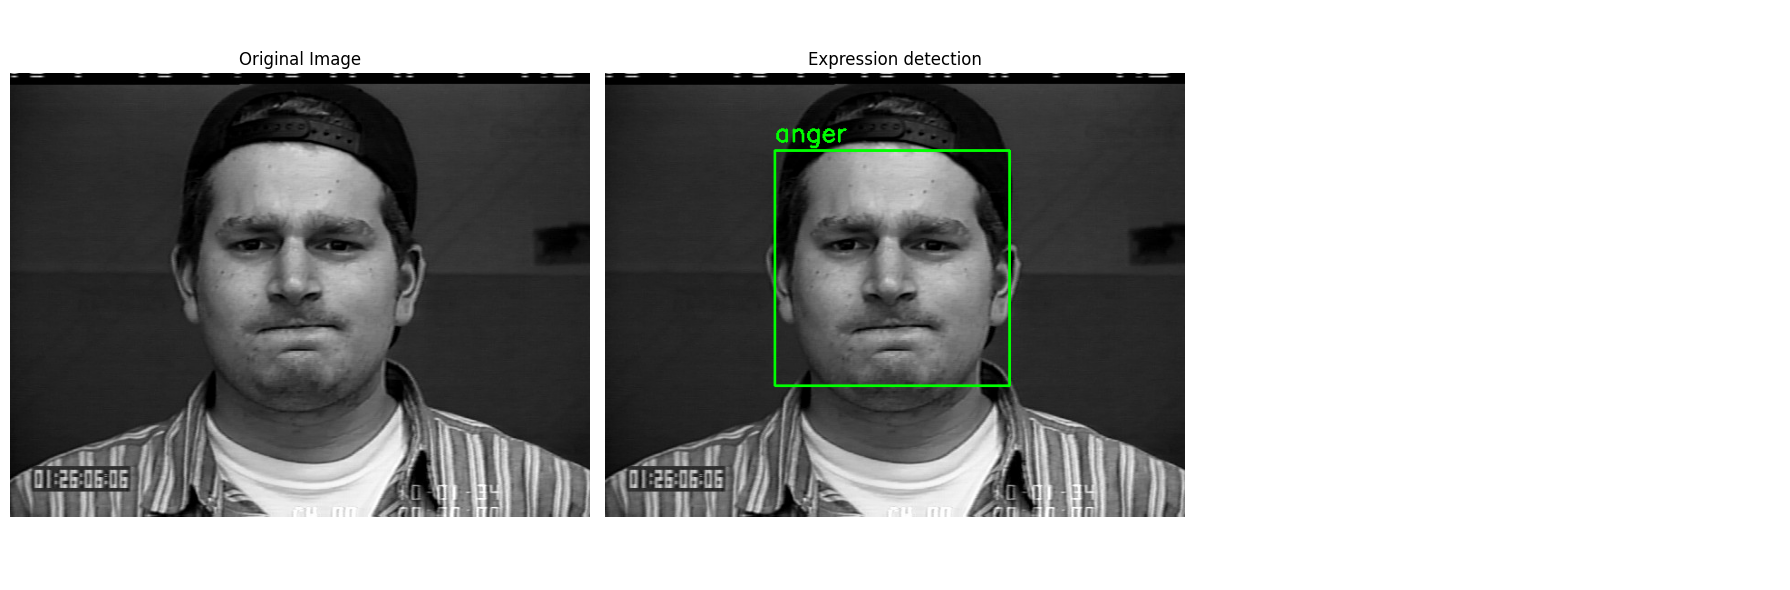

In [14]:
import cv2
import torch
import numpy as np
from matplotlib import pyplot as plt
from torchvision import transforms

# Define a function to predict the emotion
def predict_expression(image, model, device):
    # Detect the face in the image
    face = detect_face(image)
    if face is None:
        return None, None  # No face detected

    # Apply necessary transforms
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    face_tensor = transform(face).unsqueeze(0).to(device)

    # Predict the emotion using the model
    model.eval()
    with torch.no_grad():
        outputs = model(face_tensor)
        _, predicted = torch.max(outputs, 1)

    # Convert predicted label to the corresponding emotion
    emotion = train_dataset.classes[predicted.item()]
    return emotion, face

# Define function to draw bounding box and emotion text for multiple faces
def draw_faces_and_predictions(image, model, device):
    # Convert image to grayscale for face detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        print("No faces detected.")
        return image

    # Loop over all detected faces
    for (x, y, w, h) in faces:
        # Extract the face region from the image
        face = image[y:y+h, x:x+w]

        # Predict the expression of the face
        emotion, _ = predict_expression(face, model, device)
        if emotion is None:
            continue  # If no face is detected, skip

        # Draw the bounding box and the emotion label on the image
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(image, emotion, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    return image

# Test the model with a single image (handling multiple faces)
def test_single_image_multiple_faces(image_path, model, face_cascade, device):
    # Read the image
    image = cv2.imread(image_path)

    # Add a check here for whether the image was loaded successfully
    if image is None:
        print(f"Error: Could not load image from {image_path}. Please check the path and file integrity.")
        return

    image_copy = image.copy()

    # Detect faces and predict emotions
    image_with_predictions = draw_faces_and_predictions(image_copy, model, device)

    # Plot images: Original, Image with bounding boxes, and Image with predictions
    plt.figure(figsize=(18, 6))

    # 1st Image - Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    # 2nd Image - Image with bounding boxes and predictions
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(image_with_predictions, cv2.COLOR_BGR2RGB))
    plt.title('Expression detection')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    # plt.text(0.5, 0.5, 'No faces detected in the image', ha='center', va='center', fontsize=12)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# img_path = '/content/drive/My Drive/FER-testingimages/0.jpg'
# img_path = '/content/drive/My Drive/FER-testingimages/faces-crop.jpg'
img_path = '/content/drive/MyDrive/CKAGAIN/test/anger/S134_003_00000011.png'
# img_path = '/content/drive/My Drive/FER-testingimages/test-2.png'
test_single_image_multiple_faces(img_path, model, face_cascade, device)
